# Business Context (What is happening)

A small retail shop records sales transactions with the following fields:

invoice_id

Date
Product Name Category,Qty,Unit Price,TotalAmount, PaymentType

The business owner wants to understand:

How the business is performing

Which products sell the most

How customers pay

Whether sales can be predicted in the future

But currently, the data is not analyzed, contains errors, and insights are not visible.

# Problem Statement

### Problem Statement:

The business collects sales transaction data but lacks a structured system to clean, analyze, and extract insights from the data. As a result, the owner cannot clearly understand sales performance, product demand, or future revenue trends needed for better decision-making.

# Data Problems Already Visible

Before analysis we identify data quality issues (this is very important in real consulting).

**Missing values**

Example:

1006,03-01-2025,Milk,Dairy,,45,450,Cash

Qty is missing.

Extra spaces

Example:Milk Bread Rice Soap 

This creates duplicate product names.

Example:MillMilk 

The computer thinks they are different.

Date format not standardized
01-01-2025

Needs conversion to datetime.

# Analytical Questions (What We Want to Answer)

These become the project objectives.

Sales Performance

- What is the total revenue?

- What are the daily sales trends?

- What are the best selling products?

- Which product category generates most revenue?

### Customer Behavior

### What payment methods do customers prefer?

Cash vs Card

# Business Intelligence

### Which days have the highest sales?

### Which products should the business stock more?

Predictive Analytics

# Can we predict future sales based on past trends?

This can be done using:

statsmodels

scikit-learn

# Project Workflow (What You Will Do)

### A professional data science workflow:

# Step 1 — Data Cleaning

Using pandas

Tasks:

Remove extra spaces

Handle missing values

Convert dates

Verify totals

## Step 2 — Exploratory Data Analysis

Answer questions like:

revenue trends

product performance

payment analysis

## Step 3 — KPI Calculation

Examples:

Total revenue

Average order value

Best product

Best category

# Step 4 — Forecasting

Predict:

future daily sales

Step 5 — Dashboard

Display insights using:

Streamlit

Client logs in and sees:

KPIs

Charts

predictions

In [1]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
%pwd

'c:\\Users\\ASUS\\Desktop\\sales_project\\data'

In [3]:
os.chdir("../")
%pwd


'c:\\Users\\ASUS\\Desktop\\sales_project'

In [5]:
df=pd.read_csv("data/sales.csv")
df

,invoice_id,Date,Product Name,Category,Qty,Unit Price,TotalAmount,PaymentType
0,1001,01-01-2025,Milk,Dairy,10,45,450,Cash
1,1002,01-01-2025,Bread,Bakery,15,30,450,Cash
2,1003,02-01-2025,Eggs,Dairy,20,5,100,Card
3,1004,02-01-2025,Shampoo,Personal Care,5,120,600,Card
4,1005,03-01-2025,Rice,Grains,8,250,2000,Cash
5,1006,03-01-2025,Milk,Dairy,,45,450,Cash
6,1007,04-01-2025,Bread,Bakery,18,30,540,Cash
7,1008,04-01-2025,Soap,Personal Care,12,25,300,Card
8,1009,05-01-2025,Eggs,Dairy,25,5,125,Cash
9,1010,05-01-2025,Rice,Grains,6,250,1500,Card


In [ ]:
#check the info of the data
df.info()   

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   invoice_id      28 non-null     int64
 1    Date           28 non-null     str  
 2    Product Name   28 non-null     str  
 3    Category       28 non-null     str  
 4    Qty            28 non-null     str  
 5    Unit Price     28 non-null     int64
 6    TotalAmount    28 non-null     int64
 7    PaymentType    28 non-null     str  
dtypes: int64(3), str(5)
memory usage: 1.9 KB


In [8]:
#basic statics of the data
df.describe()

,invoice_id,Unit Price,TotalAmount
count,28.000000,28.000000,28.000000
mean,1014.500000,77.142857,670.357143
std,8.225975,87.901761,565.069528
min,1001.000000,5.000000,100.000000
25%,1007.750000,25.000000,356.250000
50%,1014.500000,37.500000,525.000000
75%,1021.250000,120.000000,675.000000
max,1028.000000,250.000000,2250.000000


The descriptive statistics reveal that the store processes 28 transactions within the observed period. Product prices vary widely, ranging from low-cost items such as eggs to higher-priced goods like rice. The average transaction value is approximately 670, but the high standard deviation indicates significant variation in customer spending patterns. This suggests that while some customers make small purchases, others buy larger quantities or more expensive items. Such variation provides opportunities for the business to introduce bundled promotions to increase the average transaction value.

In [9]:
#check missing values in the data
df.isnull().sum()

invoice_id        0
 Date             0
 Product Name     0
 Category         0
 Qty              0
 Unit Price       0
 TotalAmount      0
 PaymentType      0
dtype: int64

In [10]:
#check data types
df.dtypes

invoice_id        int64
 Date               str
 Product Name       str
 Category           str
 Qty                str
 Unit Price       int64
 TotalAmount      int64
 PaymentType        str
dtype: object

In [14]:
df.columns

Index(['invoice_id', ' Date      ', ' Product Name', ' Category     ', ' Qty',
       ' Unit Price', ' TotalAmount', ' PaymentType'],
      dtype='str')

In [16]:
#remove all the spaces in the column names
df.columns = df.columns.str.strip()


In [17]:
#convert date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [21]:
#fix quantity column data type
df['Qty'] = pd.to_numeric(df['Qty'], errors='coerce')

In [22]:
df.dtypes

invoice_id               int64
Date            datetime64[us]
Product Name               str
Category                   str
Qty                    float64
Unit Price               int64
TotalAmount              int64
PaymentType                str
dtype: object

In [23]:
#calculate total price for each row
df['Calculated_Total'] = df['Qty'] * df['Unit Price']

In [24]:
#compare the calculated total with the original total amount
df[['Qty','Unit Price','TotalAmount','Calculated_Total']]

,Qty,Unit Price,TotalAmount,Calculated_Total
0,10.0,45,450,450.0
1,15.0,30,450,450.0
2,20.0,5,100,100.0
3,5.0,120,600,600.0
4,8.0,250,2000,2000.0
5,NaN,45,450,NaN
6,18.0,30,540,540.0
7,12.0,25,300,300.0
8,25.0,5,125,125.0
9,6.0,250,1500,1500.0


In [26]:
df['Qty'] = df['Qty'].fillna(df['TotalAmount'] / df['Unit Price'])
df['Qty'] = df['Qty'].astype(int)
df['Calculated_Total'] = df['Qty'] * df['Unit Price']
df[['Qty','Unit Price','TotalAmount','Calculated_Total']]

,Qty,Unit Price,TotalAmount,Calculated_Total
0,10,45,450,450
1,15,30,450,450
2,20,5,100,100
3,5,120,600,600
4,8,250,2000,2000
5,10,45,450,450
6,18,30,540,540
7,12,25,300,300
8,25,5,125,125
9,6,250,1500,1500


<Axes: ylabel='TotalAmount'>

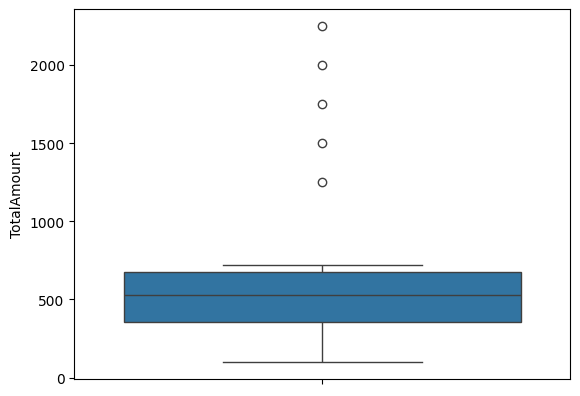

In [27]:
#check suspicioous transactions where the calculated total does not match the original total amount
import seaborn as sns
sns.boxplot(df['TotalAmount'])

The boxplot analysis of transaction values shows that most sales fall between $356 and $675, with a median transaction value of $525. Several high-value outliers were detected above $1200, indicating occasional bulk or premium product purchases. The distribution is right-skewed, suggesting a small number of transactions contribute significantly to total revenue.

In [ ]:
#checking the total revenue
total_revenue = df['TotalAmount'].sum()
print("Total Revenue:", total_revenue)


Total Revenue: 18770


In [29]:
#best selling products
df.groupby('Product Name')['Qty'].sum().sort_values(ascending=False)

Product Name
Eggs            127
Bread           111
Milk             74
Soap             37
Rice             35
Shampoo          15
Name: Qty, dtype: int64

In [30]:
#revenue by product
df.groupby('Product Name')['TotalAmount'].sum().sort_values(ascending=False)

Product Name
Rice            8750
Bread           3330
Milk            3330
Shampoo         1800
Soap             925
Eggs             635
Name: TotalAmount, dtype: int64

In [ ]:
#sales by category
df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)

Category
Grains           8750
Dairy            3965
Bakery           3330
Personal Care    2725
Name: TotalAmount, dtype: int64

In [33]:
#most used payment method
df['PaymentType'].value_counts()

PaymentType
Cash    17
Card    11
Name: count, dtype: int64

Visualization

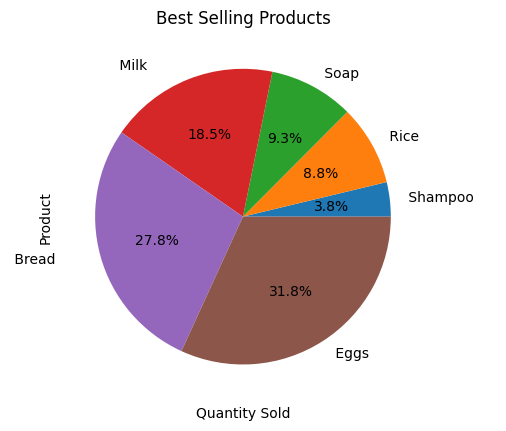

In [35]:
#best selling products


df.groupby('Product Name')['Qty'].sum().sort_values().plot(kind='pie', autopct='%1.1f%%')

plt.title("Best Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

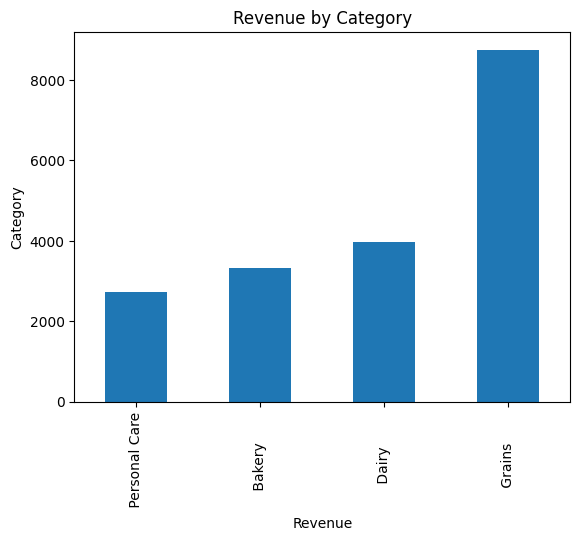

In [37]:
#revenue by category


category_revenue = df.groupby('Category')['TotalAmount'].sum().sort_values()

category_revenue.plot(kind='bar')

plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

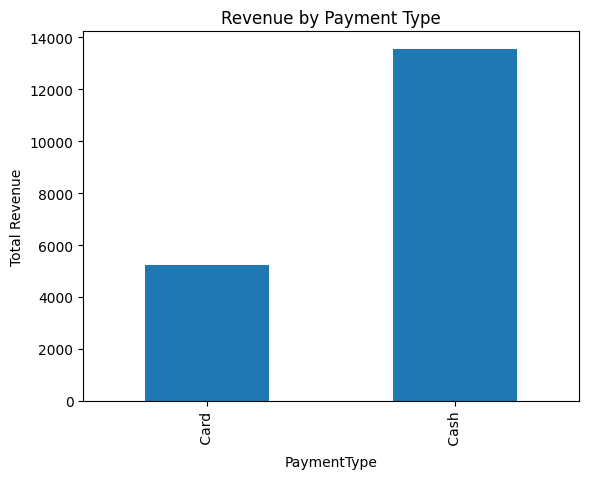

In [38]:
#revenue by payment method
df.groupby('PaymentType')['TotalAmount'].sum().plot(kind='bar')

plt.title("Revenue by Payment Type")
plt.ylabel("Total Revenue")
plt.show()

Upgrade the Dataset (Feature Engineering)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')



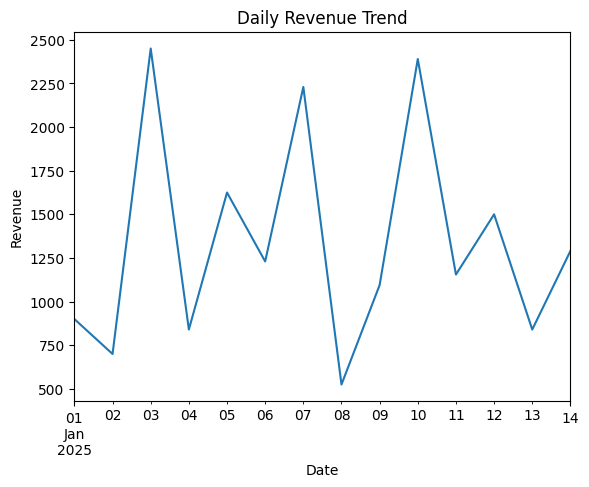

In [42]:
daily_revenue = df.groupby('Date')['TotalAmount'].sum()
daily_revenue
daily_revenue.plot()

plt.title("Daily Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Date")
plt.show()

Insight:

This plot shows how revenue changes over time.

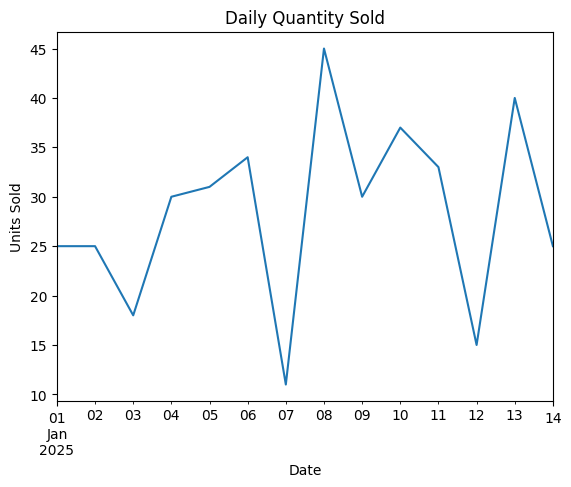

In [43]:
#Daily Total Quantity
daily_qty = df.groupby('Date')['Qty'].sum()

daily_qty.plot()

plt.title("Daily Quantity Sold")
plt.ylabel("Units Sold")
plt.xlabel("Date")
plt.show()

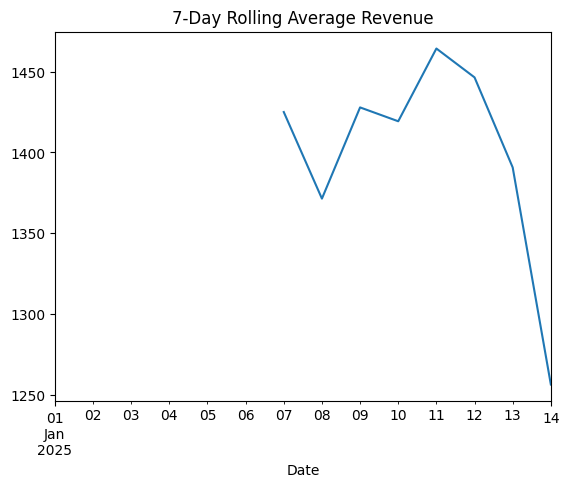

In [45]:
daily_revenue.rolling(7).mean().plot()

plt.title("7-Day Rolling Average Revenue")
plt.show()

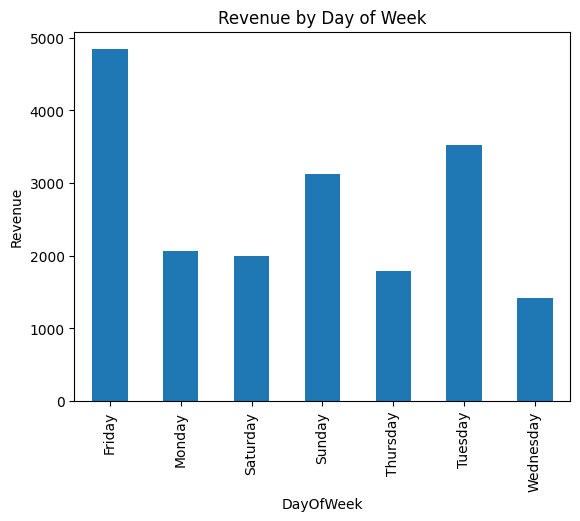

In [46]:
#day of the week feature
df['DayOfWeek'] = df['Date'].dt.day_name()
df.groupby('DayOfWeek')['TotalAmount'].sum().plot(kind='bar')

plt.title("Revenue by Day of Week")
plt.ylabel("Revenue")
plt.show()
